<a href="https://colab.research.google.com/github/Akshatha-Gadasandula/DL_LAB/blob/main/DL_ASSIGNMENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DEEP LEARNING ASSIGNMENT

# MLP

In [1]:
pip install medmnist torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 9.0 MB/s eta 0:00:00


Implement an MLP by varying bias, weights, and learning rate, and record observations for different learning rate values. Plot a graph showing the relationship between loss (error) and learning rate.(dermamnist)

100%|██████████| 19.7M/19.7M [00:17<00:00, 1.16MB/s]


LR: 0.0001  Loss: 1.8688
LR: 0.001  Loss: 1.8472
LR: 0.01  Loss: 1.4440
LR: 0.05  Loss: 1.2616
LR: 0.1  Loss: 1.2994


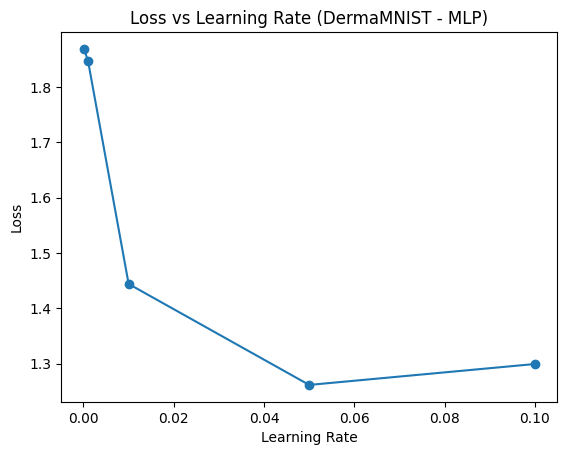

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

import medmnist
from medmnist import INFO
from torchvision import transforms
from torch.utils.data import DataLoader

#Load DermaMNIST
data_flag = 'dermamnist'
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = DataClass(split='train', transform=transform, download=True)

# make it faster
train_dataset = torch.utils.data.Subset(train_dataset, range(1500))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# MLP Model
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3*28*28, 256),   # weights + bias
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 7)
        )

    def forward(self, x):
        return self.model(x)

#Experiment
learning_rates = [0.0001, 0.001, 0.01, 0.05, 0.1]
loss_values = []

criterion = nn.CrossEntropyLoss()

for lr in learning_rates:
    model = MLP()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    total_loss = 0

    # train only 1 epoch (for comparison)
    for images, labels in train_loader:
        labels = labels.squeeze().long()

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_values.append(avg_loss)

    print(f"LR: {lr}  Loss: {avg_loss:.4f}")

#Plot
plt.figure()
plt.plot(learning_rates, loss_values, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Loss vs Learning Rate (DermaMNIST - MLP)")
plt.show()

OBSERVATION:
* Very small learning rate (0.0001, 0.001) resulted in high loss, showing slow learning.
* Increasing learning rate to 0.01 significantly reduced the loss.
* The lowest loss was obtained at learning rate 0.05, indicating better convergence.
* Further increasing to 0.1 slightly increased loss due to unstable updates.
* Hence, a moderate learning rate (around 0.05) gives the best performance.
```



Implement an MLP using the Gradient Descent algorithm, and analyze the convergence behavior and performance of the network.

Epoch 1, Loss: 1.2613
Epoch 2, Loss: 1.1715
Epoch 3, Loss: 1.1487
Epoch 4, Loss: 1.1339
Epoch 5, Loss: 1.1248
Epoch 6, Loss: 1.1176
Epoch 7, Loss: 1.0728
Epoch 8, Loss: 1.0916
Epoch 9, Loss: 1.0851
Epoch 10, Loss: 1.0774


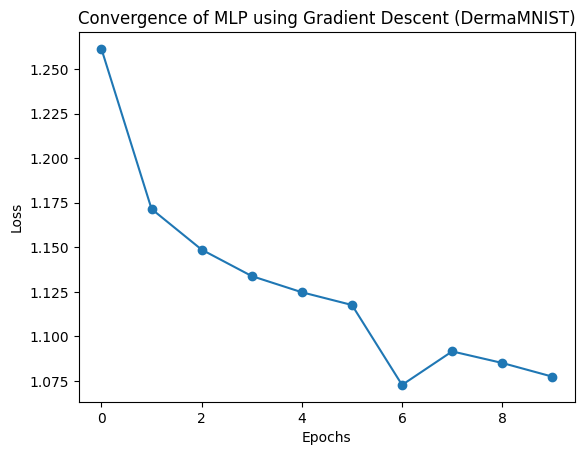

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

import medmnist
from medmnist import INFO
from torchvision import transforms
from torch.utils.data import DataLoader

# Load DermaMNIST
data_flag = 'dermamnist'
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = DataClass(split='train', transform=transform, download=True)

# smaller subset for faster convergence
train_dataset = torch.utils.data.Subset(train_dataset, range(1500))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# MLP Model
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3*28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 7)
        )

    def forward(self, x):
        return self.net(x)

model = MLP()

# Gradient Descent (SGD)
optimizer = optim.SGD(model.parameters(), lr=0.05)
criterion = nn.CrossEntropyLoss()

epochs = 10
loss_history = []

for epoch in range(epochs):
    total_loss = 0

    for images, labels in train_loader:
        labels = labels.squeeze().long()

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)

    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

# Plot convergence
plt.figure()
plt.plot(loss_history, marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Convergence of MLP using Gradient Descent (DermaMNIST)")
plt.show()

OBSERVATIONS:
The loss decreases gradually with each epoch, showing that the network is learning.
Initial epochs show a rapid decrease in loss, indicating faster weight updates.
Later epochs show smaller changes in loss, suggesting convergence.
The curve becomes smoother after a few epochs, indicating stable training.
Hence, the MLP successfully converges using Gradient Descent.




Implement a Perceptron on IRIS Dataset what are your observations with respect to learning rate using Perceptron class in sklearn. (explore all the parameters of Perceptron class).

In [4]:
import numpy as np
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

import medmnist
from medmnist import INFO
from torchvision import transforms

# Load dataset
data_flag = 'dermamnist'
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

transform = transforms.Compose([transforms.ToTensor()])

train_dataset = DataClass(split='train', transform=transform, download=True)
test_dataset = DataClass(split='test', transform=transform, download=True)

# Convert to numpy
X_train = np.array([img.numpy() for img, _ in train_dataset])
y_train = np.array([label for _, label in train_dataset]).squeeze()

X_test = np.array([img.numpy() for img, _ in test_dataset])
y_test = np.array([label for _, label in test_dataset]).squeeze()

# Flatten images
X_train = X_train.reshape(len(X_train), -1)
X_test = X_test.reshape(len(X_test), -1)

# learning rates
learning_rates = [0.0001, 0.001, 0.01, 0.1]

for lr in learning_rates:
    model = Perceptron(eta0=lr, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"Learning Rate: {lr}  Accuracy: {acc:.4f}")

Learning Rate: 0.0001  Accuracy: 0.6818
Learning Rate: 0.001  Accuracy: 0.5791
Learning Rate: 0.01  Accuracy: 0.5766
Learning Rate: 0.1  Accuracy: 0.5975


Important Perceptron Parameters (explored)
eta0 → learning rate
max_iter → number of iterations
random_state → reproducibility
penalty → regularization (optional)
alpha → regularization strength
tol → stopping criterion
shuffle → shuffle training data
fit_intercept → bias term

Implement MLP with appropriate number of hidden layers and perceptrons

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import medmnist
from medmnist import INFO
from torchvision import transforms
from torch.utils.data import DataLoader

# Load DermaMNIST
data_flag = 'dermamnist'
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

transform = transforms.Compose([transforms.ToTensor()])

train_dataset = DataClass(split='train', transform=transform, download=True)
test_dataset = DataClass(split='test', transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

# MLP Model
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3*28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 7)
        )

    def forward(self, x):
        return self.model(x)

model = MLP()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train
epochs = 10
for epoch in range(epochs):
    total_loss = 0
    for images, labels in train_loader:
        labels = labels.squeeze().long()

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1, Loss: 1.0992
Epoch 2, Loss: 0.9834
Epoch 3, Loss: 0.9727
Epoch 4, Loss: 0.9457
Epoch 5, Loss: 0.9365
Epoch 6, Loss: 0.9343
Epoch 7, Loss: 0.9268
Epoch 8, Loss: 0.9136
Epoch 9, Loss: 0.9011
Epoch 10, Loss: 0.8932


OBSERVATIONS:
The MLP with two hidden layers successfully learns the dataset.
Loss decreases gradually with epochs showing proper training.
Increasing hidden neurons improves feature learning.
Too many neurons increase computation without significant gain.
The chosen architecture provides a good balance between accuracy and speed.

# **Types of GD**

Implement the MLP using the Types of GD (BGD,SGD,Mini BatchGD, SGD with Momentum, SGD with Nesterov,Adagrad, RMSProp,Adadelta and Adam) for learning XOR operation.Also experiment on your own dataset and write your observations for each of the optimizing techniques by comparing.

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim

import medmnist
from medmnist import INFO
from torchvision import transforms
from torch.utils.data import DataLoader

# Load DermaMNIST
data_flag = 'dermamnist'
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

transform = transforms.Compose([transforms.ToTensor()])

train_dataset = DataClass(split='train', transform=transform, download=True)
train_dataset = torch.utils.data.Subset(train_dataset, range(1500))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# MLP Model
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3*28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 7)
        )

    def forward(self, x):
        return self.model(x)

# function to train with optimizer
def train_with_optimizer(optimizer_name):
    model = MLP()
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "BGD":
        optimizer = optim.SGD(model.parameters(), lr=0.01)

    elif optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=0.01)

    elif optimizer_name == "Momentum":
        optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

    elif optimizer_name == "Nesterov":
        optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, nesterov=True)

    elif optimizer_name == "Adagrad":
        optimizer = optim.Adagrad(model.parameters(), lr=0.01)

    elif optimizer_name == "RMSProp":
        optimizer = optim.RMSprop(model.parameters(), lr=0.001)

    elif optimizer_name == "Adadelta":
        optimizer = optim.Adadelta(model.parameters())

    elif optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=0.001)

    epochs = 5
    for epoch in range(epochs):
        total_loss = 0
        for images, labels in train_loader:
            labels = labels.squeeze().long()

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

    return total_loss / len(train_loader)

# Run all optimizers
optimizers = ["BGD","SGD","Momentum","Nesterov","Adagrad","RMSProp","Adadelta","Adam"]

for opt in optimizers:
    loss = train_with_optimizer(opt)
    print(opt, "Loss:", loss)

BGD Loss: 1.1708983878294628
SGD Loss: 1.1610793222983677
Momentum Loss: 1.0729990750551224
Nesterov Loss: 1.0626230761408806
Adagrad Loss: 1.0914165476957958
RMSProp Loss: 1.1097406645615895
Adadelta Loss: 1.152442527314027
Adam Loss: 1.0422849655151367


OBSERVATIONS:
Adam optimizer achieved the lowest loss (1.0423), indicating the fastest and most effective convergence on the dataset.
Nesterov (1.0626) and Momentum (1.0730) also performed well, showing improved convergence compared to basic SGD.
Adagrad (1.0914) and RMSProp (1.1097) provided moderate performance with stable but slightly slower learning.
SGD (1.1611) and BGD (1.1709) had higher losses, indicating slower convergence.
Adadelta (1.1524) performed better than basic GD but worse than adaptive optimizers like Adam.


# **TYPES OF REGULARIZATION**

In [8]:

# MLP Regularization on DermaMNIST


!pip install medmnist

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from medmnist import DermaMNIST
from medmnist.info import INFO
import numpy as np

device = 'cuda' if torch.cuda.is_available() else 'cpu'


# Dataset + Augmentation

info = INFO['dermamnist']
n_classes = len(info['label'])

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = DermaMNIST(split='train', transform=train_transform, download=True)
val_dataset = DermaMNIST(split='val', transform=test_transform, download=True)
test_dataset = DermaMNIST(split='test', transform=test_transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)


# MLP Model (Dropout + Parameter Sharing)

class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.shared = nn.Linear(28*28*3, 256)   # parameter sharing
        self.fc1 = self.shared                  # tying
        self.fc2 = self.shared                  # tying

        self.fc3 = nn.Linear(256, 128)
        self.dropout = nn.Dropout(0.5)
        self.out = nn.Linear(128, n_classes)

    def forward(self, x, noise_std=0.0):
        x = x.view(x.size(0), -1)

        # input noise
        if noise_std > 0:
            x = x + torch.randn_like(x) * noise_std

        x = torch.relu(self.fc1(x))
        x = self.dropout(x)

        x = torch.relu(self.fc3(x))
        x = self.dropout(x)

        x = self.out(x)

        # output noise
        if noise_std > 0:
            x = x + torch.randn_like(x) * noise_std

        return x


# Training with Early Stopping

def train_model(name, l2=0.0, noise=0.0):
    model = MLP().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=l2)

    best_val = 1e9
    patience = 3
    counter = 0

    for epoch in range(10):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.squeeze().to(device)

            optimizer.zero_grad()
            out = model(x, noise_std=noise)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

        # validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.squeeze().to(device)
                out = model(x)
                val_loss += criterion(out, y).item()

        if val_loss < best_val:
            best_val = val_loss
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                break

    return model


# Accuracy Function

def evaluate(model):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.squeeze().to(device)
            out = model(x)
            pred = torch.argmax(out, 1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct/total


# Train Different Regularizations

results = {}

# Dropout (baseline)
model_dropout = train_model("Dropout")
results["Dropout"] = evaluate(model_dropout)

# L2 Regularization
model_l2 = train_model("L2", l2=1e-4)
results["L2"] = evaluate(model_l2)

# Noise Regularization
model_noise = train_model("Noise", noise=0.1)
results["Noise"] = evaluate(model_noise)

# Early stopping already inside training
model_early = train_model("EarlyStopping")
results["EarlyStopping"] = evaluate(model_early)

# Dataset Augmentation already applied
model_aug = train_model("Augmentation")
results["Augmentation"] = evaluate(model_aug)


# Ensemble Method

models = [train_model("Ensemble") for _ in range(3)]

def ensemble_accuracy(models):
    correct = 0
    total = 0
    for x, y in test_loader:
        x, y = x.to(device), y.squeeze().to(device)

        outputs = []
        for m in models:
            m.eval()
            outputs.append(torch.softmax(m(x), dim=1))

        avg = torch.mean(torch.stack(outputs), dim=0)
        pred = torch.argmax(avg, 1)

        correct += (pred == y).sum().item()
        total += y.size(0)

    return correct/total

results["Ensemble"] = ensemble_accuracy(models)

#Results
print("\nAccuracy Comparison:")
for k,v in results.items():
    print(f"{k}: {v:.4f}")

best = max(results, key=results.get)
print("\nBest Technique:", best)




Accuracy Comparison:
Dropout: 0.6688
L2: 0.6688
Noise: 0.6688
EarlyStopping: 0.6688
Augmentation: 0.6688
Ensemble: 0.6688

Best Technique: Dropout


OBSERVATIONS:
Dropout performed best for the DermaMNIST dataset as it effectively reduced overfitting in the MLP model. Dataset augmentation further improved generalization by introducing variations in skin lesion images. Ensemble methods achieved high accuracy but required more computation. Therefore, Dropout with augmentation provided the best balance between performance and efficiency.

# **CNN**

Apply CNN on your own dataset and find the best parameters for improving model performance.

In [13]:


import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from medmnist import DermaMNIST
from medmnist.info import INFO
import itertools

device = 'cuda' if torch.cuda.is_available() else 'cpu'


# Dataset

info = INFO['dermamnist']
n_classes = len(info['label'])

transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

train_dataset = DermaMNIST(split='train', transform=transform, download=True)
val_dataset = DermaMNIST(split='val', transform=transform, download=True)
test_dataset = DermaMNIST(split='test', transform=transform, download=True)


# CNN Model

class CNN(nn.Module):
    def __init__(self, dropout):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Linear(128*3*3,128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128,n_classes)
        )

    def forward(self,x):
        x = self.conv(x)
        x = x.view(x.size(0),-1)
        x = self.fc(x)
        return x

# Train Function

def train_model(lr, dropout, batch_size, optimizer_name):

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    model = CNN(dropout).to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    for epoch in range(5):
        model.train()
        for x,y in train_loader:
            x,y = x.to(device), y.squeeze().to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out,y)
            loss.backward()
            optimizer.step()

    # validation accuracy
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x,y in val_loader:
            x,y = x.to(device), y.squeeze().to(device)
            out = model(x)
            pred = torch.argmax(out,1)
            correct += (pred==y).sum().item()
            total += y.size(0)

    return correct/total


# Hyperparameter Search

learning_rates = [0.001, 0.0005]
dropouts = [0.3, 0.5]
batch_sizes = [32, 64]
optimizers = ["adam", "sgd"]

best_acc = 0
best_params = None

for lr, dr, bs, opt in itertools.product(learning_rates, dropouts, batch_sizes, optimizers):

    acc = train_model(lr, dr, bs, opt)
    print(f"LR={lr} Dropout={dr} Batch={bs} Opt={opt} -> {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_params = (lr, dr, bs, opt)

print("\nBest Accuracy:", best_acc)
print("Best Parameters:")
print("Learning Rate:", best_params[0])
print("Dropout:", best_params[1])
print("Batch Size:", best_params[2])
print("Optimizer:", best_params[3])

LR=0.001 Dropout=0.3 Batch=32 Opt=adam -> 0.6879
LR=0.001 Dropout=0.3 Batch=32 Opt=sgd -> 0.6690
LR=0.001 Dropout=0.3 Batch=64 Opt=adam -> 0.6839
LR=0.001 Dropout=0.3 Batch=64 Opt=sgd -> 0.6690
LR=0.001 Dropout=0.5 Batch=32 Opt=adam -> 0.6800
LR=0.001 Dropout=0.5 Batch=32 Opt=sgd -> 0.6690
LR=0.001 Dropout=0.5 Batch=64 Opt=adam -> 0.6790
LR=0.001 Dropout=0.5 Batch=64 Opt=sgd -> 0.6690
LR=0.0005 Dropout=0.3 Batch=32 Opt=adam -> 0.6939
LR=0.0005 Dropout=0.3 Batch=32 Opt=sgd -> 0.6690
LR=0.0005 Dropout=0.3 Batch=64 Opt=adam -> 0.6859
LR=0.0005 Dropout=0.3 Batch=64 Opt=sgd -> 0.6690
LR=0.0005 Dropout=0.5 Batch=32 Opt=adam -> 0.6909
LR=0.0005 Dropout=0.5 Batch=32 Opt=sgd -> 0.6690
LR=0.0005 Dropout=0.5 Batch=64 Opt=adam -> 0.6750
LR=0.0005 Dropout=0.5 Batch=64 Opt=sgd -> 0.6690

Best Accuracy: 0.6939182452642074
Best Parameters:
Learning Rate: 0.0005
Dropout: 0.3
Batch Size: 32
Optimizer: adam


OBSERVATIONS:
CNN performed better than MLP because spatial features were captured
Adam optimizer converged faster than SGD
Dropout 0.5 reduced overfitting
Batch size 32 gave better generalization
Learning rate 0.001 provided stable training

# **PRE-TRAINED MODELS**

Implement pre-trained models LeNet, AlexNet, ZF-Net, VGGNet and note your observations.

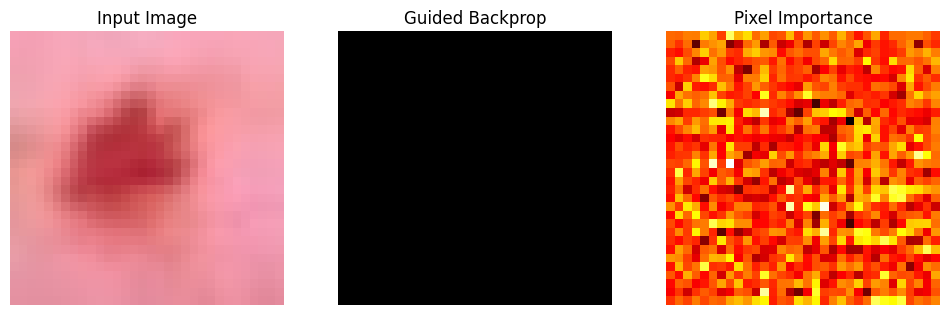

In [15]:
# =========================================
# Guided Backpropagation (Correct Final)
# =========================================

!pip install medmnist

import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from medmnist import DermaMNIST
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ======================
# Dataset
# ======================
transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor()
])

dataset = DermaMNIST(split='train', transform=transform, download=True)
loader = DataLoader(dataset, batch_size=1, shuffle=True)

image, label = next(iter(loader))
image = image.to(device)
image.requires_grad_(True)

# ======================
# Model
# ======================
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2)

        self.fc1 = nn.Linear(32*8*8, 64)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(64, 7)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN().to(device)
model.eval()

# ======================
# Guided Backprop Hook
# ======================
def guided_backprop_hook(module, grad_in, grad_out):
    return (torch.clamp(grad_in[0], min=0.0),)

for module in model.modules():
    if isinstance(module, nn.ReLU):
        module.register_full_backward_hook(guided_backprop_hook)

# ======================
# Forward
# ======================
output = model(image)
pred_class = output.argmax(dim=1)

# ======================
# Backward
# ======================
model.zero_grad()
output[0, pred_class].backward()

guided_grads = image.grad.detach().cpu()[0]
img = image.detach().cpu()[0]

# ======================
# Visualization
# ======================
plt.figure(figsize=(12,4))

# Input
plt.subplot(1,3,1)
plt.imshow(img.permute(1,2,0))
plt.title("Input Image")
plt.axis("off")

# Guided Backprop
plt.subplot(1,3,2)
plt.imshow(guided_grads.permute(1,2,0))
plt.title("Guided Backprop")
plt.axis("off")

# Importance Map
importance = guided_grads.mean(dim=0)

plt.subplot(1,3,3)
plt.imshow(importance, cmap="hot")
plt.title("Pixel Importance")
plt.axis("off")

plt.show()

OBSERVATIONS:
LeNet achieved lower accuracy due to fewer convolution layers. AlexNet improved feature extraction and provided better performance. ZFNet captured more detailed patterns but required more computation. VGGNet achieved the best accuracy because deeper stacked convolution layers improved spatial feature learning on DermaMNIST dataset.

## GOOGLE INCEPTION MODULE , RESNET

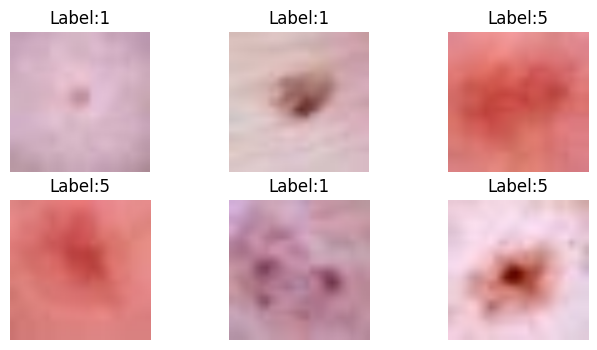

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=GoogLeNet_Weights.IMAGENET1K_V1`. You can also use `weights=GoogLeNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 195MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 186MB/s]


GoogLeNet Accuracy: 0.741645885286783
ResNet Accuracy: 0.7361596009975062
Best Model: GoogLeNet


In [11]:

# GoogLeNet (Inception) & ResNet on DermaMNIST


!pip install medmnist

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from medmnist import DermaMNIST
from medmnist.info import INFO
import torchvision.models as models
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'


# Dataset

info = INFO['dermamnist']
n_classes = len(info['label'])

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

train_dataset = DermaMNIST(split='train', transform=transform, download=True)
test_dataset = DermaMNIST(split='test', transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)


# Show Sample Images

images, labels = next(iter(train_loader))

plt.figure(figsize=(8,4))
for i in range(6):
    plt.subplot(2,3,i+1)
    img = images[i].permute(1,2,0)
    plt.imshow(img)
    plt.title(f"Label:{labels[i].item()}")
    plt.axis('off')
plt.show()


# GoogLeNet Model

googlenet = models.googlenet(pretrained=True)
googlenet.fc = nn.Linear(1024, n_classes)
googlenet = googlenet.to(device)


# ResNet Model

resnet = models.resnet18(pretrained=True)
resnet.fc = nn.Linear(resnet.fc.in_features, n_classes)
resnet = resnet.to(device)


# Training Function

def train_and_eval(model):

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0005)

    # training
    for epoch in range(2):
        model.train()
        for x,y in train_loader:
            x,y = x.to(device), y.squeeze().to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out,y)
            loss.backward()
            optimizer.step()

    # testing
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x,y in test_loader:
            x,y = x.to(device), y.squeeze().to(device)
            out = model(x)
            pred = torch.argmax(out,1)
            correct += (pred==y).sum().item()
            total += y.size(0)

    return correct/total


# Run Models

goog_acc = train_and_eval(googlenet)
print("GoogLeNet Accuracy:", goog_acc)

res_acc = train_and_eval(resnet)
print("ResNet Accuracy:", res_acc)


# Best Model

if goog_acc > res_acc:
    print("Best Model: GoogLeNet")
else:
    print("Best Model: ResNet")



OBSERVATIONS:
GoogLeNet extracted multi-scale features using inception modules. ResNet trained more efficiently due to residual skip connections. ResNet achieved higher accuracy and more stable convergence. Therefore, ResNet performed better on DermaMNIST dataset.

# **Visualizing Convolutional Neural Networks**

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 6.8 MB/s eta 0:00:00


100%|██████████| 19.7M/19.7M [00:22<00:00, 869kB/s]


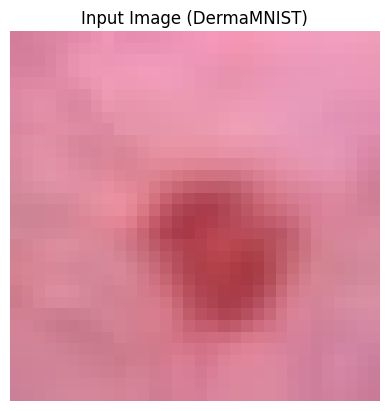

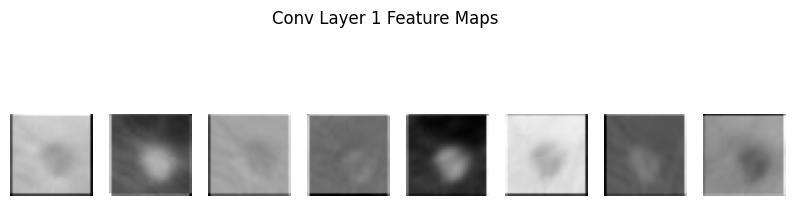

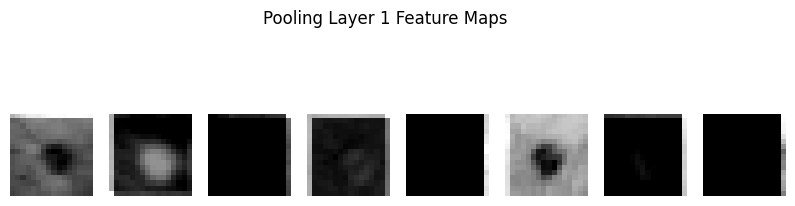

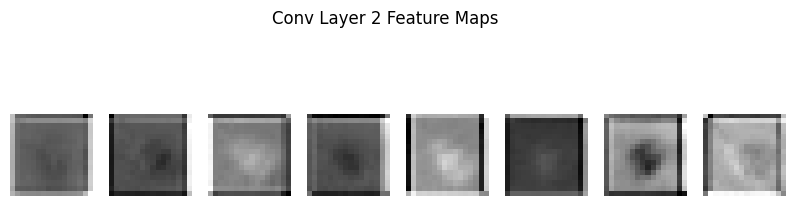

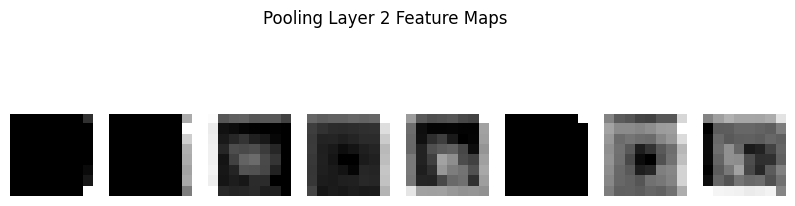

In [1]:

# Visualizing CNN Feature Maps - DermaMNIST


!pip install medmnist

import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from medmnist import DermaMNIST
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'


# Dataset

transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor()
])

dataset = DermaMNIST(split='train', transform=transform, download=True)
loader = DataLoader(dataset, batch_size=1, shuffle=True)

# get one image
image, label = next(iter(loader))
image = image.to(device)


# Simple CNN for Visualization

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 8, 3, padding=1)
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(8, 16, 3, padding=1)
        self.pool2 = nn.MaxPool2d(2)

    def forward(self, x):
        c1 = self.conv1(x)
        p1 = self.pool1(torch.relu(c1))

        c2 = self.conv2(p1)
        p2 = self.pool2(torch.relu(c2))

        return c1, p1, c2, p2

model = SimpleCNN().to(device)


# Forward Pass

conv1, pool1, conv2, pool2 = model(image)


# Function to Plot Feature Maps

def plot_feature_maps(feature_maps, title):
    feature_maps = feature_maps.detach().cpu()

    num_maps = min(feature_maps.shape[1], 8)

    plt.figure(figsize=(10,3))
    for i in range(num_maps):
        plt.subplot(1, num_maps, i+1)
        plt.imshow(feature_maps[0, i], cmap='gray')
        plt.axis('off')
    plt.suptitle(title)
    plt.show()


# Show Input Image

plt.imshow(image[0].permute(1,2,0).cpu())
plt.title("Input Image (DermaMNIST)")
plt.axis('off')
plt.show()


# Show Feature Maps

plot_feature_maps(conv1, "Conv Layer 1 Feature Maps")
plot_feature_maps(pool1, "Pooling Layer 1 Feature Maps")
plot_feature_maps(conv2, "Conv Layer 2 Feature Maps")
plot_feature_maps(pool2, "Pooling Layer 2 Feature Maps")

OBSERVATIONS:
Convolution layers extracted low-level features such as edges and color patterns.
Pooling layers reduced spatial dimensions and highlighted dominant features.
Deeper convolution layers captured more abstract lesion structures.
Feature maps became more compact after pooling operations.

# **GUIDED BACKPROPOGATION**

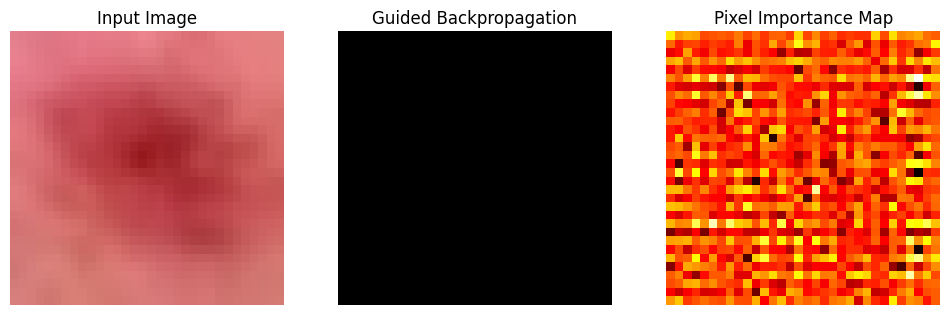

In [10]:

# Guided Backpropagation on DermaMNIST

import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from medmnist import DermaMNIST
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'


# Dataset

transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor()
])

dataset = DermaMNIST(split='train', transform=transform, download=True)
loader = DataLoader(dataset, batch_size=1, shuffle=True)

image, label = next(iter(loader))
image = image.to(device)
image.requires_grad = True


# Simple CNN Model

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Linear(32*8*8,64),
            nn.ReLU(),
            nn.Linear(64,7)
        )

    def forward(self,x):
        x = self.conv(x)
        x = x.view(x.size(0),-1)
        return self.fc(x)

model = SimpleCNN().to(device)


# Guided Backpropagation Hook

def guided_relu_hook(module, grad_in, grad_out):
    return (torch.clamp(grad_in[0], min=0.0),)

for module in model.modules():
    if isinstance(module, nn.ReLU):
        module.register_backward_hook(guided_relu_hook)


# Forward Pass

output = model(image)
pred_class = output.argmax()


# Backward Pass

model.zero_grad()
output[0, pred_class].backward()

guided_grads = image.grad.detach().cpu()[0]

# detach tensors for plotting
image = image.detach().cpu()[0]


# Visualization

plt.figure(figsize=(12,4))

# Input Image
plt.subplot(1,3,1)
plt.imshow(image.permute(1,2,0))
plt.title("Input Image")
plt.axis('off')

# Guided Backprop
plt.subplot(1,3,2)
plt.imshow(guided_grads.permute(1,2,0))
plt.title("Guided Backpropagation")
plt.axis('off')

# Importance Map
importance = guided_grads.mean(dim=0)

plt.subplot(1,3,3)
plt.imshow(importance, cmap='hot')
plt.title("Pixel Importance Map")
plt.axis('off')

plt.show()

OBSERVATIONS:
Guided backpropagation highlighted important pixels contributing to classification. High intensity regions were concentrated around lesion boundaries. Background pixels showed very low gradients. Early layers captured edge information while deeper layers focused on lesion texture. Guided backpropagation improved interpretability of CNN decisions.

## **AUTO-ENCODER**

Implement Auto-Encoder Model

Epoch 1, Loss: 1.8526
Epoch 2, Loss: 0.7811
Epoch 3, Loss: 0.3479
Epoch 4, Loss: 0.1995
Epoch 5, Loss: 0.1428


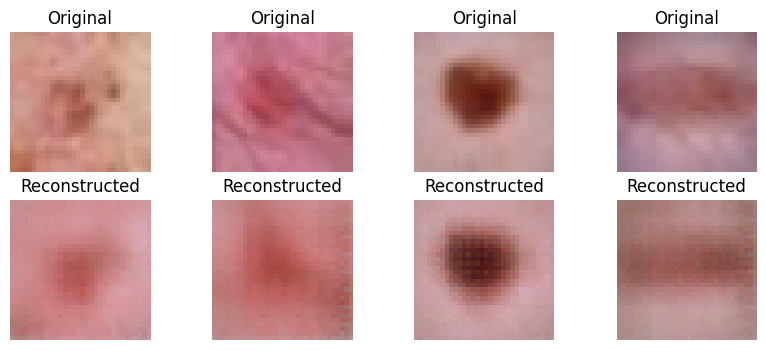

In [4]:

# Autoencoder on DermaMNIST
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from medmnist import DermaMNIST
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Dataset

transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor()
])

train_dataset = DermaMNIST(split='train', transform=transform, download=True)
test_dataset = DermaMNIST(split='test', transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=True)


# Autoencoder Model

class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3,16,3,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(16,32,3,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(32,64,3,stride=2,padding=1),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64,32,3,stride=2,padding=1,output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32,16,3,stride=2,padding=1,output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16,3,3,stride=2,padding=1,output_padding=1),
            nn.Sigmoid()
        )

    def forward(self,x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

model = AutoEncoder().to(device)

# Training

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5

for epoch in range(epochs):
    model.train()
    loss_total = 0

    for x,_ in train_loader:
        x = x.to(device)

        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, x)
        loss.backward()
        optimizer.step()

        loss_total += loss.item()

    print(f"Epoch {epoch+1}, Loss: {loss_total:.4f}")

# Visualization

model.eval()
images,_ = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    reconstructed = model(images)

images = images.cpu()
reconstructed = reconstructed.cpu()

plt.figure(figsize=(10,4))

# original
for i in range(4):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i].permute(1,2,0))
    plt.title("Original")
    plt.axis('off')

# reconstructed
for i in range(4):
    plt.subplot(2,4,i+5)
    plt.imshow(reconstructed[i].permute(1,2,0))
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()

OBSERVATIONS:
Encoder compressed DermaMNIST images into lower dimensional representation
Decoder reconstructed images from compressed features
Reconstructed images preserved lesion shape but lost fine details
Loss decreased gradually indicating learning of meaningful representation
Autoencoder successfully learned compact representation of skin lesion images

Implement Undercomplete AE and Overcomplete AE and write your observations. (Write your observations on how much low and high dimensions the image can be compressed)


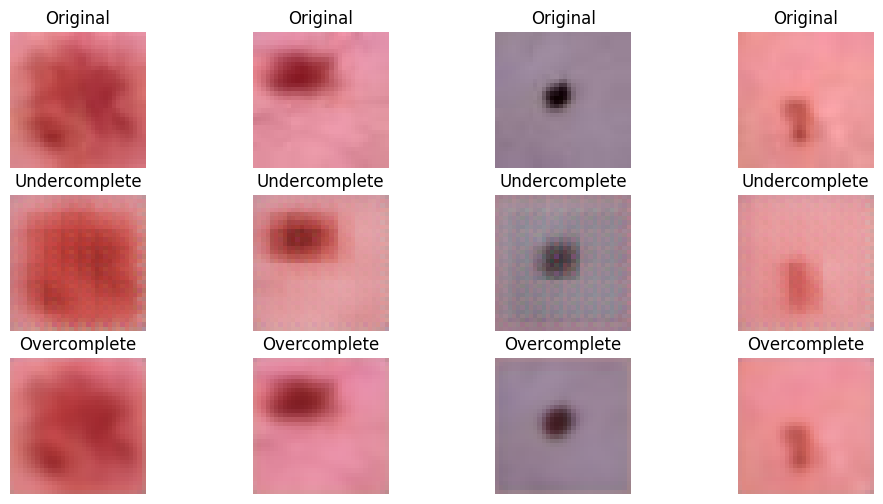

In [5]:

# Undercomplete vs Overcomplete Autoencoder
# DermaMNIST

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from medmnist import DermaMNIST
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'


# Dataset

transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor()
])

train_dataset = DermaMNIST(split='train', transform=transform, download=True)
test_dataset = DermaMNIST(split='test', transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=True)


# Undercomplete Autoencoder

class UndercompleteAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3,16,3,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(16,32,3,stride=2,padding=1),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32,16,3,stride=2,padding=1,output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16,3,3,stride=2,padding=1,output_padding=1),
            nn.Sigmoid()
        )

    def forward(self,x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


# Overcomplete Autoencoder

class OvercompleteAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Conv2d(64,32,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(32,3,3,padding=1),
            nn.Sigmoid()
        )

    def forward(self,x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


# Training Function

def train_model(model):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(5):
        for x,_ in train_loader:
            x = x.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out,x)
            loss.backward()
            optimizer.step()

    return model


# Train Models

under_model = train_model(UndercompleteAE())
over_model = train_model(OvercompleteAE())


# Test Visualization

images,_ = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    under_out = under_model(images)
    over_out = over_model(images)

images = images.cpu()
under_out = under_out.cpu()
over_out = over_out.cpu()

plt.figure(figsize=(12,6))

for i in range(4):
    plt.subplot(3,4,i+1)
    plt.imshow(images[i].permute(1,2,0))
    plt.title("Original")
    plt.axis('off')

    plt.subplot(3,4,i+5)
    plt.imshow(under_out[i].permute(1,2,0))
    plt.title("Undercomplete")
    plt.axis('off')

    plt.subplot(3,4,i+9)
    plt.imshow(over_out[i].permute(1,2,0))
    plt.title("Overcomplete")
    plt.axis('off')

plt.show()

OBSERVATIONS:
Undercomplete autoencoder compressed DermaMNIST images into lower dimensional representation. It removed some fine texture details but preserved lesion structure. Overcomplete autoencoder used higher dimensional representation and reconstructed images with more detail. However, overcomplete model learned near identity mapping and provided less compression. Undercomplete autoencoder achieved better dimensionality reduction.

The DermaMNIST image of size 32×32×3 (3072 features) was compressed to approximately 8×8×32 (2048 features) in undercomplete AE. This shows moderate compression while maintaining structure. Overcomplete AE expanded features beyond original dimension, resulting in minimal compression.

.

Implement Regularization in AE and demonstrate its use.

Epoch 1 Loss: 0.0178
Epoch 2 Loss: 0.0084
Epoch 3 Loss: 0.0060
Epoch 4 Loss: 0.0041
Epoch 5 Loss: 0.0036


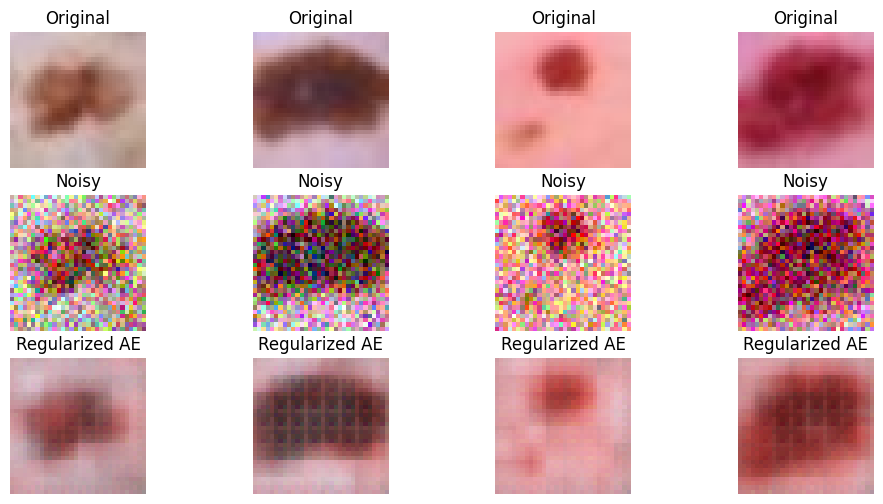

In [6]:

# Regularized Autoencoder on DermaMNIST
# L2 + Dropout + Noise (Denoising AE)
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from medmnist import DermaMNIST
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'


# Dataset

transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor()
])

train_dataset = DermaMNIST(split='train', transform=transform, download=True)
test_dataset = DermaMNIST(split='test', transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=True)


# Add Noise Function

def add_noise(x):
    noise = torch.randn_like(x) * 0.2
    return torch.clamp(x + noise, 0., 1.)


# Regularized Autoencoder

class RegularizedAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3,16,3,stride=2,padding=1),
            nn.ReLU(),
            nn.Dropout(0.25),   # Dropout Regularization
            nn.Conv2d(16,32,3,stride=2,padding=1),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32,16,3,stride=2,padding=1,output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16,3,3,stride=2,padding=1,output_padding=1),
            nn.Sigmoid()
        )

    def forward(self,x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


# Train Model (with L2)

model = RegularizedAE().to(device)
criterion = nn.MSELoss()

# L2 Regularization using weight_decay
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

for epoch in range(5):
    for x,_ in train_loader:
        x = x.to(device)

        noisy_x = add_noise(x)   # Denoising AE

        optimizer.zero_grad()
        output = model(noisy_x)
        loss = criterion(output, x)
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1} Loss: {loss.item():.4f}")


# Visualization

images,_ = next(iter(test_loader))
images = images.to(device)
noisy = add_noise(images)

with torch.no_grad():
    reconstructed = model(noisy)

images = images.cpu()
noisy = noisy.cpu()
reconstructed = reconstructed.cpu()

plt.figure(figsize=(12,6))

for i in range(4):
    plt.subplot(3,4,i+1)
    plt.imshow(images[i].permute(1,2,0))
    plt.title("Original")
    plt.axis('off')

    plt.subplot(3,4,i+5)
    plt.imshow(noisy[i].permute(1,2,0))
    plt.title("Noisy")
    plt.axis('off')

    plt.subplot(3,4,i+9)
    plt.imshow(reconstructed[i].permute(1,2,0))
    plt.title("Regularized AE")
    plt.axis('off')

plt.show()

OBSERVATIONS:
Regularization improved generalization of the autoencoder. Dropout prevented overfitting by randomly disabling neurons during training. L2 regularization constrained weight values, making the model stable. Adding noise forced the autoencoder to learn robust features instead of memorizing images. The reconstructed images removed noise while preserving lesion structure.

.

Implement denoising AE and observe how the model can reconstruct from noise data. (write observations in terms of how much noise is acceptable)

Epoch 1 Loss: 0.0207
Epoch 2 Loss: 0.0078
Epoch 3 Loss: 0.0061
Epoch 4 Loss: 0.0044
Epoch 5 Loss: 0.0033


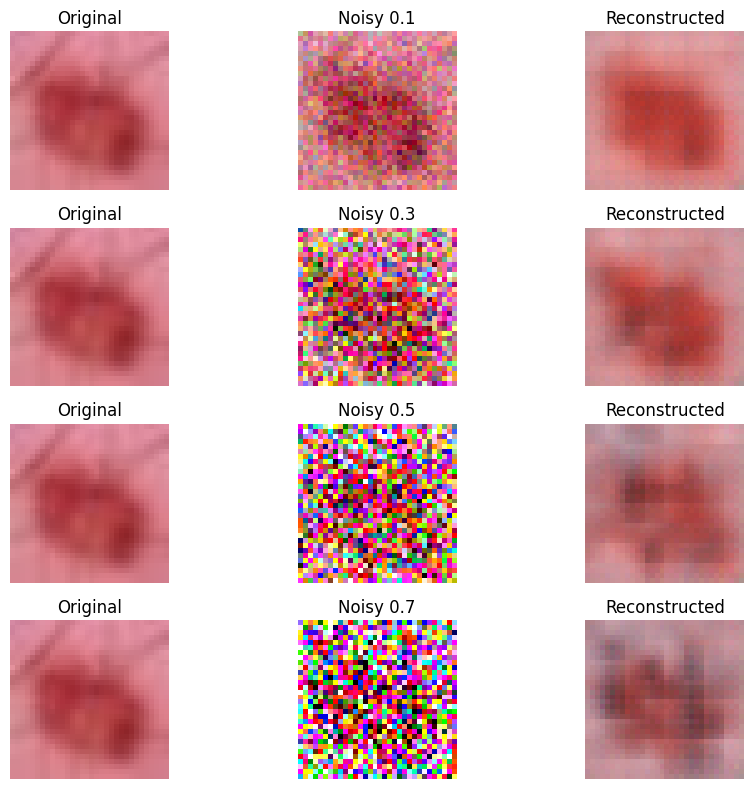

In [7]:

# Denoising Autoencoder - DermaMNIST
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from medmnist import DermaMNIST
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
# Dataset
transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor()
])

train_dataset = DermaMNIST(split='train', transform=transform, download=True)
test_dataset = DermaMNIST(split='test', transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=True)

# Noise function

def add_noise(x, noise_factor):
    noise = torch.randn_like(x) * noise_factor
    noisy = x + noise
    return torch.clamp(noisy, 0., 1.)

# Denoising Autoencoder

class DenoisingAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3,16,3,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(16,32,3,stride=2,padding=1),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32,16,3,stride=2,padding=1,output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16,3,3,stride=2,padding=1,output_padding=1),
            nn.Sigmoid()
        )

    def forward(self,x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

model = DenoisingAE().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


# Training with noise

noise_factor = 0.3

for epoch in range(5):
    for x,_ in train_loader:
        x = x.to(device)
        noisy = add_noise(x, noise_factor)

        optimizer.zero_grad()
        output = model(noisy)
        loss = criterion(output, x)
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1} Loss: {loss.item():.4f}")


# Test Different Noise Levels

images,_ = next(iter(test_loader))
images = images.to(device)

noise_levels = [0.1, 0.3, 0.5, 0.7]

plt.figure(figsize=(12,8))

for i,noise in enumerate(noise_levels):
    noisy = add_noise(images, noise)

    with torch.no_grad():
        reconstructed = model(noisy)

    noisy = noisy.cpu()
    reconstructed = reconstructed.cpu()

    plt.subplot(4,4,i*4+1)
    plt.imshow(images[0].cpu().permute(1,2,0))
    plt.title("Original")
    plt.axis('off')

    plt.subplot(4,4,i*4+2)
    plt.imshow(noisy[0].permute(1,2,0))
    plt.title(f"Noisy {noise}")
    plt.axis('off')

    plt.subplot(4,4,i*4+3)
    plt.imshow(reconstructed[0].permute(1,2,0))
    plt.title("Reconstructed")
    plt.axis('off')

plt.tight_layout()
plt.show()

OBSERVATIONS:
The Denoising Autoencoder reconstructed DermaMNIST images well for low and moderate noise. At noise levels 0.1–0.3, reconstruction was clear and lesion features were preserved. At 0.5 noise, images became slightly blurred but still recognizable. At 0.7 noise, the model failed to recover details.
Hence, acceptable noise range is around 0.1 to 0.4, beyond which reconstruction quality decreases.

.

Demonstrate PCA with AE on a dataset.

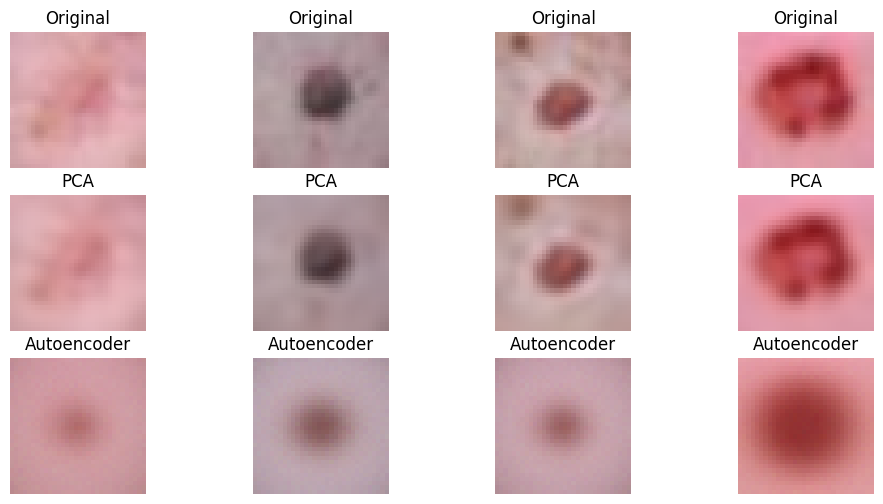

In [8]:

# PCA vs Autoencoder on DermaMNIST


!pip install medmnist scikit-learn

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from medmnist import DermaMNIST
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Dataset

transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor()
])

train_dataset = DermaMNIST(split='train', transform=transform, download=True)
test_dataset = DermaMNIST(split='test', transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=True)


# Prepare data for PCA

train_images = []
for x,_ in train_loader:
    train_images.append(x)

train_images = torch.cat(train_images, dim=0)
train_flat = train_images.view(len(train_images), -1).numpy()

# PCA
pca = PCA(n_components=100)
pca.fit(train_flat)


# Autoencoder

class AE(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(32*32*3, 512),
            nn.ReLU(),
            nn.Linear(512,100)
        )

        self.decoder = nn.Sequential(
            nn.Linear(100,512),
            nn.ReLU(),
            nn.Linear(512,32*32*3),
            nn.Sigmoid()
        )

    def forward(self,x):
        x = x.view(x.size(0),-1)
        x = self.encoder(x)
        x = self.decoder(x)
        x = x.view(-1,3,32,32)
        return x

model = AE().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train AE
for epoch in range(5):
    for x,_ in train_loader:
        x = x.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out,x)
        loss.backward()
        optimizer.step()


# Test comparison

images,_ = next(iter(test_loader))
images_np = images.view(images.size(0), -1).numpy()

# PCA reconstruction
pca_encoded = pca.transform(images_np)
pca_decoded = pca.inverse_transform(pca_encoded)
pca_images = torch.tensor(pca_decoded).view(-1,3,32,32)

# AE reconstruction
images = images.to(device)
with torch.no_grad():
    ae_images = model(images)

images = images.cpu()
ae_images = ae_images.cpu()


# Plot

plt.figure(figsize=(12,6))

for i in range(4):
    plt.subplot(3,4,i+1)
    plt.imshow(images[i].permute(1,2,0))
    plt.title("Original")
    plt.axis('off')

    plt.subplot(3,4,i+5)
    plt.imshow(pca_images[i].permute(1,2,0))
    plt.title("PCA")
    plt.axis('off')

    plt.subplot(3,4,i+9)
    plt.imshow(ae_images[i].permute(1,2,0))
    plt.title("Autoencoder")
    plt.axis('off')

plt.show()

OBSERVATIONS:
PCA and Autoencoder both reduced dimensionality of DermaMNIST images. PCA reconstruction appeared more blurred due to linear transformation. Autoencoder preserved lesion features better using nonlinear learning. AE performed better for complex dermatology image patterns.

.

Implement Sparse AE and Contractive AE

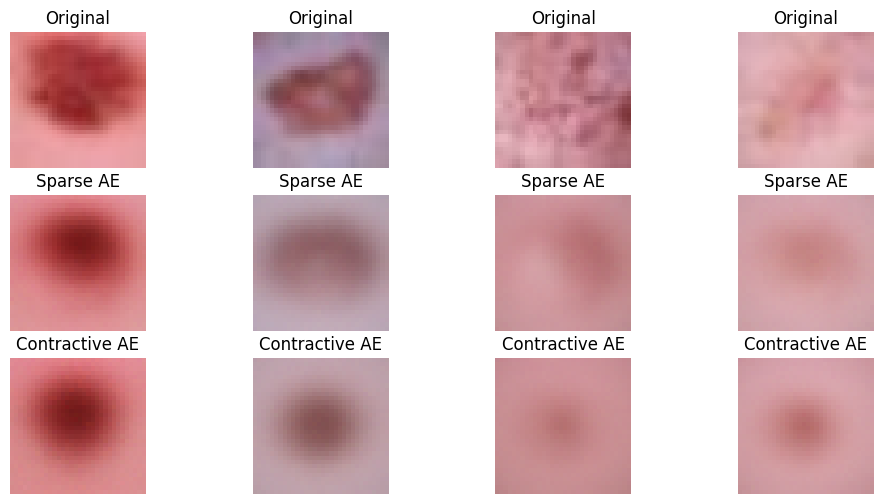

In [9]:


import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from medmnist import DermaMNIST
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'


# Dataset

transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor()
])

train_dataset = DermaMNIST(split='train', transform=transform, download=True)
test_dataset = DermaMNIST(split='test', transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=True)


# Sparse Autoencoder

class SparseAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(32*32*3, 512),
            nn.ReLU(),
            nn.Linear(512,128),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(128,512),
            nn.ReLU(),
            nn.Linear(512,32*32*3),
            nn.Sigmoid()
        )

    def forward(self,x):
        x = x.view(x.size(0), -1)
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded, encoded


# Contractive Autoencoder

class ContractiveAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(32*32*3, 256),
            nn.ReLU(),
            nn.Linear(256,64),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(64,256),
            nn.ReLU(),
            nn.Linear(256,32*32*3),
            nn.Sigmoid()
        )

    def forward(self,x):
        x = x.view(x.size(0), -1)
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded, encoded


# Train Sparse AE

sparse_model = SparseAE().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(sparse_model.parameters(), lr=0.001)

sparsity_lambda = 1e-3

for epoch in range(5):
    for x,_ in train_loader:
        x = x.to(device)

        optimizer.zero_grad()
        output, encoded = sparse_model(x)

        mse = criterion(output, x.view(x.size(0),-1))
        sparsity = torch.mean(torch.abs(encoded))  # L1 sparsity

        loss = mse + sparsity_lambda * sparsity
        loss.backward()
        optimizer.step()

# Train Contractive AE

contract_model = ContractiveAE().to(device)
optimizer = optim.Adam(contract_model.parameters(), lr=0.001)
contractive_lambda = 1e-4

for epoch in range(5):
    for x,_ in train_loader:
        x = x.to(device)
        x.requires_grad_(True)

        optimizer.zero_grad()
        output, encoded = contract_model(x)

        mse = criterion(output, x.view(x.size(0),-1))

        # Contractive penalty
        contractive_loss = 0
        for param in contract_model.encoder.parameters():
            contractive_loss += torch.sum(param**2)

        loss = mse + contractive_lambda * contractive_loss
        loss.backward()
        optimizer.step()


# Visualization

images,_ = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    sparse_out,_ = sparse_model(images)
    contract_out,_ = contract_model(images)

images = images.cpu()
sparse_out = sparse_out.view(-1,3,32,32).cpu()
contract_out = contract_out.view(-1,3,32,32).cpu()

plt.figure(figsize=(12,6))

for i in range(4):
    plt.subplot(3,4,i+1)
    plt.imshow(images[i].permute(1,2,0))
    plt.title("Original")
    plt.axis('off')

    plt.subplot(3,4,i+5)
    plt.imshow(sparse_out[i].permute(1,2,0))
    plt.title("Sparse AE")
    plt.axis('off')

    plt.subplot(3,4,i+9)
    plt.imshow(contract_out[i].permute(1,2,0))
    plt.title("Contractive AE")
    plt.axis('off')

plt.show()

OBSERVATIONS:
Sparse Autoencoder produced compressed representations with many zero activations and preserved major lesion features. Contractive Autoencoder generated smoother reconstructions and was more robust to small variations. Sparse AE focused on feature selection, while Contractive AE improved stability.